Initial Data:
(10, 2)
(10,)
Combined Data:
(13, 2)
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]
(13,)
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]


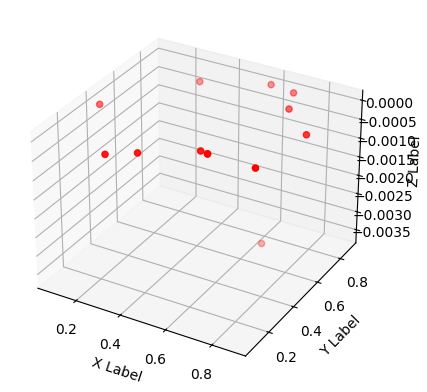

In [3]:
# load data from npy files
import numpy as np
import os

# Load initial data
input = np.load('./initial_data/function_1/initial_inputs.npy')
output = np.load('./initial_data/function_1/initial_outputs.npy')

print("Initial Data:")
print(input.shape)
print(output.shape)

# Helper to parse the text files
def parse_data_file(filename, function_idx=0):
    data_list = []
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        return data_list
    
    with open(filename, 'r') as f:
        content = f.read()
        
    # Parse content by balancing brackets to handle multi-line lists and multiple lists
    balance = 0
    start_idx = -1
    
    for i, char in enumerate(content):
        if char == '[':
            if balance == 0:
                start_idx = i
            balance += 1
        elif char == ']':
            balance -= 1
            if balance == 0 and start_idx != -1:
                block = content[start_idx : i+1]
                try:
                    # The file format is like [array([...]), ...] or [np.float64(...), ...]
                    parsed = eval(block, {"array": np.array, "np": np})
                    if isinstance(parsed, list) and len(parsed) > function_idx:
                        data_list.append(parsed[function_idx])
                except Exception as e:
                    print(f"Failed to parse block in {filename}: {e}")
                start_idx = -1
                
    return data_list

# Load additional data
# Note: User mentioned input.txt/output.txt but files are inputs.txt/outputs.txt
# We will try to load inputs.txt/inputs2.txt and outputs.txt/outputs2.txt
new_inputs = []
new_inputs.extend(parse_data_file('inputs.txt'))
new_inputs.extend(parse_data_file('inputs2.txt'))

new_outputs = []
new_outputs.extend(parse_data_file('outputs.txt'))
new_outputs.extend(parse_data_file('outputs2.txt'))

# Append if we found new data
if new_inputs:
    # Check if new_inputs contains valid arrays
    valid_inputs = [x for x in new_inputs if isinstance(x, np.ndarray)]
    if valid_inputs:
        new_inputs_arr = np.array(valid_inputs)
        # Ensure dimensions match
        if new_inputs_arr.ndim == input.ndim and new_inputs_arr.shape[1] == input.shape[1]:
            input = np.vstack((input, new_inputs_arr))
        else:
            print(f"Warning: Dimension mismatch. Initial: {input.shape}, New: {new_inputs_arr.shape}")

if new_outputs:
    new_outputs_arr = np.array(new_outputs)
    output = np.append(output, new_outputs_arr)

print("Combined Data:")
print(input.shape)
print(input[:10])
print(output.shape)
print(output[:10])

# visualize data in a 3D plot
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(input[:,0], input[:,1], output, c='r', marker='o')
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
plt.show()

In [4]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from scipy.stats import norm

# -----------------------------------------------------------
# 1. Define the search space (bounds for each of the 2 dims)
# -----------------------------------------------------------
# Replace these with the real min/max for your problem
bounds = np.array([
    [0.0, 1.0],  # bounds for dimension 0
    [0.0, 1.0],  # bounds for dimension 1
])

# -----------------------------------------------------------
# 2. Fit a Gaussian Process on your existing data
#    Assumes you already have:
#       input  -> shape (n_samples, 2)
#       output -> shape (n_samples,) or (n_samples, 1)
# -----------------------------------------------------------

# Make sure output is 1D
y = np.asarray(output).ravel()
X = np.asarray(input)

kernel = ConstantKernel(1.0, (0.1, 10.0)) * Matern(length_scale=0.5, nu=2.5) \
         + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=5,
    normalize_y=True,
    random_state=0,
)

gp.fit(X, y)

# -----------------------------------------------------------
# 3. Define Expected Improvement (EI) acquisition function
# -----------------------------------------------------------

def expected_improvement(X_candidates, gp, y_best, xi=0.01):
    """
    X_candidates: array of shape (n_candidates, 2)
    gp: fitted GaussianProcessRegressor
    y_best: current best observed value
    xi: exploration parameter (small >0 encourages exploration)
    """
    mu, sigma = gp.predict(X_candidates, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)

    # Avoid division by zero
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0

    return ei.ravel()

# -----------------------------------------------------------
# 4. Propose the next point by maximizing EI
#    (here we use random search over the box defined by `bounds`)
# -----------------------------------------------------------

def sample_random_points(bounds, n_points, random_state=None):
    rng = np.random.default_rng(random_state)
    dim = bounds.shape[0]
    return rng.uniform(bounds[:, 0], bounds[:, 1], size=(n_points, dim))

def propose_next_point(input, output, bounds, n_candidates=10000, xi=0.01, random_state=0):
    X = np.asarray(input)
    y = np.asarray(output).ravel()

    # Fit a new GP (you can reuse the earlier one if you like)
    kernel = ConstantKernel(1.0, (0.1, 10.0)) * Matern(length_scale=0.5, nu=2.5) \
             + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=5,
        normalize_y=True,
        random_state=random_state,
    )
    gp.fit(X, y)

    y_best = y.max()

    # Sample candidate points in the search space
    X_candidates = sample_random_points(bounds, n_candidates, random_state=random_state)

    # Compute EI over candidates
    ei = expected_improvement(X_candidates, gp, y_best, xi=xi)

    # Choose the candidate with the highest EI
    best_idx = np.argmax(ei)
    x_next = X_candidates[best_idx]

    return x_next, ei[best_idx], gp

# -----------------------------------------------------------
# 5. Actually get the next point to sample
# -----------------------------------------------------------

x_next, ei_value, gp_model = propose_next_point(input, output, bounds)

print("Next point to sample:", x_next)
print("EI at that point:", ei_value)

Next point to sample: [0.04097352 0.01652764]
EI at that point: 3.045641307674328e-29


/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decr

In [5]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from scipy.stats import norm

# -----------------------------------------------------------
# Generic utilities (work for any dimension D)
# -----------------------------------------------------------

def sample_random_points(bounds, n_points, random_state=None):
    """
    Sample n_points uniformly inside a hyper-rectangle.
    
    bounds: array of shape (D, 2), where D = dimensionality
            bounds[i, 0] = lower bound for dim i
            bounds[i, 1] = upper bound for dim i
    """
    rng = np.random.default_rng(random_state)
    bounds = np.asarray(bounds)
    D = bounds.shape[0]
    return rng.uniform(bounds[:, 0], bounds[:, 1], size=(n_points, D))


def expected_improvement(X_candidates, gp, y_best, xi=0.01):
    """
    Expected Improvement acquisition function.
    
    X_candidates: (n_candidates, D)
    gp: fitted GaussianProcessRegressor
    y_best: best observed target value so far
    xi: exploration parameter
    """
    mu, sigma = gp.predict(X_candidates, return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)

    # avoid division by zero
    sigma = np.maximum(sigma, 1e-9)

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    ei[sigma == 0.0] = 0.0

    return ei.ravel()


def fit_gp_model(X, y, random_state=0):
    """
    Fit a Gaussian Process model to the data.
    Works for any X.shape = (n_samples, D).
    """
    kernel = ConstantKernel(1.0, (0.1, 10.0)) * Matern(length_scale=0.5, nu=2.5) \
             + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))

    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=5,
        normalize_y=True,
        random_state=random_state,
    )
    gp.fit(X, y)
    return gp


def propose_next_point(input, output, bounds, n_candidates=10000, xi=0.01, random_state=0):
    """
    Propose the next point to sample by maximizing Expected Improvement.
    
    input:   array of shape (n_samples, D)
    output:  array of shape (n_samples,) or (n_samples, 1)
    bounds:  array of shape (D, 2)
    """
    X = np.asarray(input)
    y = np.asarray(output).ravel()
    
    # Fit GP on current data
    gp = fit_gp_model(X, y, random_state=random_state)
    y_best = y.max()

    # Sample candidate points in D-dimensional space
    X_candidates = sample_random_points(bounds, n_candidates, random_state=random_state)

    # Compute EI and pick the best
    ei = expected_improvement(X_candidates, gp, y_best, xi=xi)
    best_idx = np.argmax(ei)

    x_next = X_candidates[best_idx]
    ei_value = ei[best_idx]
    return x_next, ei_value, gp

# -----------------------------------------------------------
# Example usage for 3D, 4D, ..., 8D
# -----------------------------------------------------------

# Assume you already have:
#   input  -> shape (n_samples, D)
#   output -> shape (n_samples,) or (n_samples, 1)

# D = input.shape[1]
# You must define bounds with shape (D, 2)

# Example: 5D problem (generalizes to 3D–8D)
# bounds = np.array([
#     [0.0, 1.0],   # dim 0
#     [-1.0, 2.0],  # dim 1
#     [10.0, 20.0], # dim 2
#     [0.0, 5.0],   # dim 3
#     [100.0, 200.0]# dim 4
# ])

# Get next point to evaluate:
# x_next, ei_value, gp_model = propose_next_point(input, output, bounds)
# print("Next point to sample:", x_next)
# print("EI at that point:", ei_value)

def infer_bounds_from_data(input, pad_ratio=0.05, min_bound=0.0):
    """
    Infer bounds from the existing samples.
    pad_ratio = % margin added beyond min/max (default 5%).
    min_bound = minimum allowed lower bound (default 0.0 for non-negative inputs).
    """
    X = np.asarray(input)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    
    # Add padding to allow exploration
    padding = (maxs - mins) * pad_ratio
    mins -= padding
    maxs += padding
    
    # Ensure lower bounds are not below min_bound (non-negative constraint)
    mins = np.maximum(mins, min_bound)
    
    return np.vstack([mins, maxs]).T   # shape (D, 2)

In [6]:
x_next, ei_value, gp_model = propose_next_point(input, output, bounds)

print("Next point to sample:", x_next)
print("EI at that point:", ei_value)

Next point to sample: [0.04097352 0.01652764]
EI at that point: 3.045641307674328e-29


/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [7]:
input = np.load('./initial_data/function_2/initial_inputs.npy')
output = np.load('./initial_data/function_2/initial_outputs.npy')

In [8]:
x_next, ei_value, gp_model = propose_next_point(input, output, bounds)

print("Next point to sample:", x_next)
print("EI at that point:", ei_value)

Next point to sample: [0.77536717 0.93522844]
EI at that point: 0.03965901262113387


In [9]:
input = np.load('./initial_data/function_3/initial_inputs.npy')
output = np.load('./initial_data/function_3/initial_outputs.npy')

In [10]:
bounds = infer_bounds_from_data(input)
x_next, ei_value, gp_model = propose_next_point(input, output, bounds)

print("Next point to sample:", x_next)
print("EI at that point:", ei_value)

Next point to sample: [0.36227252 0.32987054 0.46428246]
EI at that point: 0.018389453339689815


In [11]:
input = np.load('./initial_data/function_4/initial_inputs.npy')
output = np.load('./initial_data/function_4/initial_outputs.npy')
bounds = infer_bounds_from_data(input)
x_next, ei_value, gp_model = propose_next_point(input, output, bounds)

print("Next point to sample:", x_next)
print("EI at that point:", ei_value)

Next point to sample: [0.41231429 0.43525724 0.37968496 0.45540797]
EI at that point: 2.1038697662663526


/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [12]:
input = np.load('./initial_data/function_5/initial_inputs.npy')
output = np.load('./initial_data/function_5/initial_outputs.npy')
bounds = infer_bounds_from_data(input)
x_next, ei_value, gp_model = propose_next_point(input, output, bounds)

print("Next point to sample:", x_next)
print("EI at that point:", ei_value)

Next point to sample: [0.33484391 0.76782965 0.90168002 0.95212843]
EI at that point: 22.577848213361325


/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.1. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [13]:
input = np.load('./initial_data/function_6/initial_inputs.npy')
output = np.load('./initial_data/function_6/initial_outputs.npy')
bounds = infer_bounds_from_data(input)
x_next, ei_value, gp_model = propose_next_point(input, output, bounds)

print("Next point to sample:", x_next)
print("EI at that point:", ei_value)

print(input[:10])



Next point to sample: [0.44926962 0.29555001 0.60715799 0.88105951 0.09502001]
EI at that point: 0.17370398922178804
[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]]


In [14]:
input = np.load('./initial_data/function_7/initial_inputs.npy')
output = np.load('./initial_data/function_7/initial_outputs.npy')
bounds = infer_bounds_from_data(input)
x_next, ei_value, gp_model = propose_next_point(input, output, bounds)

print("Next point to sample:", x_next)
print("EI at that point:", ei_value)

Next point to sample: [0.11344864 0.37843724 0.18481049 0.14666923 0.38426408 0.82102123]
EI at that point: 0.006494823830710948


In [15]:
input = np.load('./initial_data/function_8/initial_inputs.npy')
output = np.load('./initial_data/function_8/initial_outputs.npy')
bounds = infer_bounds_from_data(input)
x_next, ei_value, gp_model = propose_next_point(input, output, bounds)

print("Next point to sample:", x_next)
print("EI at that point:", ei_value)

Next point to sample: [0.06198661 0.2902905  0.08099564 0.34221114 0.82687476 0.35392966
 0.19195278 0.54906213]
EI at that point: 0.5365227294703907


/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [16]:
input.shape


(40, 8)

In [17]:
# -----------------------------------------------------------
# Load submitted guesses from inputs.txt and outputs.txt
# and merge with initial data for next round of prediction
# -----------------------------------------------------------

import numpy as np
import ast

def load_submitted_results(inputs_path='./inputs.txt', outputs_path='./outputs.txt'):
    """
    Parse inputs.txt and outputs.txt files.
    Returns list of input arrays and list of output values.
    """
    with open(inputs_path, 'r') as f:
        inputs_str = f.read()
    with open(outputs_path, 'r') as f:
        outputs_str = f.read()
    
    # Parse inputs - they are stored as a list of arrays
    # Replace 'array(' with 'np.array(' for eval
    inputs_str = inputs_str.replace('array(', 'np.array(')
    submitted_inputs = eval(inputs_str)
    
    # Parse outputs - they are stored as a list of np.float64
    outputs_str = outputs_str.replace('np.float64(', '').replace(')', '')
    # Now it's a list of floats as a string
    submitted_outputs = ast.literal_eval(outputs_str)
    
    return submitted_inputs, submitted_outputs

def load_and_merge_data(function_num, submitted_inputs, submitted_outputs):
    """
    Load initial data for a function and merge with submitted results.
    
    function_num: 1-8
    submitted_inputs: list of input arrays (one per function)
    submitted_outputs: list of output values (one per function)
    
    Returns merged (input, output) arrays
    """
    # Load initial data
    initial_input = np.load(f'./initial_data/function_{function_num}/initial_inputs.npy')
    initial_output = np.load(f'./initial_data/function_{function_num}/initial_outputs.npy')
    
    # Get the submitted result for this function (0-indexed)
    new_input = submitted_inputs[function_num - 1].reshape(1, -1)
    new_output = np.array([submitted_outputs[function_num - 1]])
    
    # Merge
    merged_input = np.vstack([initial_input, new_input])
    merged_output = np.concatenate([initial_output, new_output])
    
    return merged_input, merged_output

# Load submitted results
submitted_inputs, submitted_outputs = load_submitted_results()

print("Submitted inputs:")
for i, inp in enumerate(submitted_inputs):
    print(f"  Function {i+1}: {inp}")

print("\nSubmitted outputs:")
for i, out in enumerate(submitted_outputs):
    print(f"  Function {i+1}: {out}")

Submitted inputs:
  Function 1: [0.636961 0.269786]
  Function 2: [0.775367 0.935228]
  Function 3: [0.362272 0.32987  0.464282]
  Function 4: [0.406567 0.413614 0.378049 0.455407]
  Function 5: [0.334843 0.767374 0.90168  0.952128]
  Function 6: [0.436817 0.383543 0.554628 0.797327 0.137013]
  Function 7: [0.180791 0.561635 0.262563 0.092443 0.350958 0.757753]
  Function 8: [0.024602 0.257988 0.057126 0.319432 0.818966 0.336596 0.182213 0.546531]

Submitted outputs:
  Function 1: -3.7575017851843855e-49
  Function 2: 0.15045239985000647
  Function 3: -0.009024416135224828
  Function 4: -0.2275871522809214
  Function 5: 1328.9395067907012
  Function 6: -0.17333697427490538
  Function 7: 1.055928868589898
  Function 8: 9.9045304428679


In [18]:
# -----------------------------------------------------------
# Run next round of predictions for all 8 functions
# -----------------------------------------------------------

def check_output_status(new_output, original_outputs):
    """
    Check if new_output is a new max, new min, or in between.
    
    Returns: 
        - 'NEW MAX' if new_output > all original outputs
        - 'NEW MIN' if new_output < all original outputs
        - 'IN BETWEEN' otherwise
    """
    orig_max = np.max(original_outputs)
    orig_min = np.min(original_outputs)
    
    if new_output > orig_max:
        return 'NEW MAX', f"(prev max: {orig_max:.6f}, improvement: +{new_output - orig_max:.6f})"
    elif new_output < orig_min:
        return 'NEW MIN', f"(prev min: {orig_min:.6f}, diff: {new_output - orig_min:.6f})"
    else:
        return 'IN BETWEEN', f"(range: [{orig_min:.6f}, {orig_max:.6f}])"

next_points = []
best_points = []

print("=" * 60)
print("CHECKING SUBMITTED RESULTS vs ORIGINAL DATA")
print("=" * 60)

for func_num in range(1, 9):
    # Load original data
    original_input = np.load(f'./initial_data/function_{func_num}/initial_inputs.npy')
    original_output = np.load(f'./initial_data/function_{func_num}/initial_outputs.npy')
    
    # Get submitted result for this function
    submitted_output = submitted_outputs[func_num - 1]
    
    # Check status
    status, details = check_output_status(submitted_output, original_output)
    print(f"Function {func_num}: {status} {details}")
    print(f"  Submitted: {submitted_output:.6f}")

print("\n" + "=" * 60)
print("NEXT ROUND OF PREDICTIONS")
print("=" * 60)

for func_num in range(1, 9):
    print(f"\n--- Function {func_num} ---")
    
    # Load and merge data
    merged_input, merged_output = load_and_merge_data(func_num, submitted_inputs, submitted_outputs)
    print(f"Data: {merged_input.shape[0]} samples, {merged_input.shape[1]}D")
    
    # Find current best
    best_idx = np.argmax(merged_output)
    print(f"Best output: {merged_output[best_idx]:.6f} at {merged_input[best_idx]}")
    best_points.append((merged_input[best_idx], merged_output[best_idx]))
    
    # Infer bounds and propose next point
    bounds = infer_bounds_from_data(merged_input)
    x_next, ei_value, gp_model = propose_next_point(merged_input, merged_output, bounds)
    
    print(f"Next point: {x_next}, EI: {ei_value:.6f}")
    next_points.append(x_next)

# -----------------------------------------------------------
# Summary for easy submission (dash-separated format)
# -----------------------------------------------------------
print("\n" + "=" * 60)
print("SUBMISSION FORMAT (dash-separated)")
print("=" * 60)
for i, pt in enumerate(next_points):
    formatted = "-".join([f"{v:.6f}" for v in pt])
    print(f"Function {i+1}: {formatted}")

/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


CHECKING SUBMITTED RESULTS vs ORIGINAL DATA
Function 1: IN BETWEEN (range: [-0.003606, 0.000000])
  Submitted: -0.000000
Function 2: IN BETWEEN (range: [-0.065624, 0.611205])
  Submitted: 0.150452
Function 3: NEW MAX (prev max: -0.034835, improvement: +0.025811)
  Submitted: -0.009024
Function 4: NEW MAX (prev max: -4.025542, improvement: +3.797955)
  Submitted: -0.227587
Function 5: NEW MAX (prev max: 1088.859618, improvement: +240.079889)
  Submitted: 1328.939507
Function 6: NEW MAX (prev max: -0.714265, improvement: +0.540928)
  Submitted: -0.173337
Function 7: IN BETWEEN (range: [0.002701, 1.364968])
  Submitted: 1.055929
Function 8: NEW MAX (prev max: 9.598482, improvement: +0.306048)
  Submitted: 9.904530

NEXT ROUND OF PREDICTIONS

--- Function 1 ---
Data: 11 samples, 2D
Best output: 0.000000 at [0.73102363 0.73299988]
Next point: [0.60393312 0.27642512], EI: 0.000000

--- Function 2 ---
Data: 11 samples, 2D
Best output: 0.611205 at [0.70263656 0.9265642 ]
Next point: [0.6209924

/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Next point: [0.43200114 0.76797319 0.8895906  0.99305412], EI: 44.267599

--- Function 6 ---
Data: 21 samples, 5D
Best output: -0.173337 at [0.436817 0.383543 0.554628 0.797327 0.137013]
Next point: [0.21564877 0.30954275 0.41149099 0.87246351 0.03589965], EI: 0.130345

--- Function 7 ---
Data: 31 samples, 6D
Best output: 1.364968 at [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
Next point: [0.11344864 0.37843724 0.18481049 0.14666923 0.38426408 0.82102123], EI: 0.006717

--- Function 8 ---
Data: 41 samples, 8D
Best output: 9.904530 at [0.024602 0.257988 0.057126 0.319432 0.818966 0.336596 0.182213 0.546531]
Next point: [0.05675893 0.3356909  0.00602197 0.32662368 0.30555437 0.86483318
 0.05972003 0.37706939], EI: 0.090413

SUBMISSION FORMAT (dash-separated)
Function 1: 0.603933-0.276425
Function 2: 0.620992-0.264541
Function 3: 0.437734-0.186311-0.442866
Function 4: 0.446876-0.418270-0.338072-0.465675
Function 5: 0.432001-0.767973-0.889591-0.993054
Function 6: 0.

/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/roychan/Documents/personal/study/imperial/ml/capstone1/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
